# 📰 EDA & PREPROCESSING — FP TEXT MINING
**Topic Modeling Berita Online: Multi-Label Classification**

Dataset: Scraping multi-portal (Detik, Antara, Tribun, Kompas, Liputan6, CNN Indonesia)

Notebook ini mencakup:
1. Load Data
2. EDA — Exploratory Data Analysis
3. Preprocessing (Cleaning → Normalisasi → Stopword Removal → Stemming)
4. Post-Preprocessing EDA
5. Simpan Corpus

In [63]:
from google.colab import drive
import os

# Unmount if already mounted, and remove the directory to ensure a clean state
if os.path.exists('/content/drive'):
    try:
        drive.flush_and_unmount()
    except ValueError:
        pass # Drive might not be mounted, ignore error
    finally:
        os.system('rm -rf /content/drive') # Force remove directory content

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


---
## 0. Setup & Import Library

In [64]:
!pip install PySastrawi wordcloud tqdm -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import os
import json
import warnings
warnings.filterwarnings('ignore')

from tqdm.auto import tqdm
tqdm.pandas()

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = 'Set2'

print('✅ Semua library berhasil diimport')

✅ Semua library berhasil diimport


In [65]:
# Setup direktori output
SAVE_DIR = '/content/drive/MyDrive/TextMining/FP_TopicModelling'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Save dir: {SAVE_DIR}')

Save dir: /content/drive/MyDrive/TextMining/FP_TopicModelling


---
## 1. Load Data

In [66]:
# Load dari GitHub repo FP
URL = 'https://raw.githubusercontent.com/Siriuslys/fp-textmining/main/dataset_berita.csv'
df_raw = pd.read_csv(URL)

print(f'Shape awal  : {df_raw.shape}')
print(f'Kolom       : {df_raw.columns.tolist()}')
print()
df_raw.head(3)

Shape awal  : (10392, 6)
Kolom       : ['portal', 'kategori', 'judul', 'tanggal', 'isi', 'url']



,portal,kategori,judul,tanggal,isi,url
0,detik,ekonomi,VKTR Kirim 30 Bus Listrik ke Transjakarta Sepa...,"Rabu, 27 Mei 2026 16:00 WIB","PT VKTR Teknologi Mobilitas Tbk (VKTR), emiten...",https://finance.detik.com/bursa-dan-valas/d-85...
1,detik,ekonomi,"Batal Berangkat Haji, Purbaya Pakai Duitnya bu...","Rabu, 27 Mei 2026 09:02 WIB",Menteri Keuangan (Menkeu) Purbaya Yudhi Sadewa...,https://finance.detik.com/berita-ekonomi-bisni...
2,detik,ekonomi,"PT DSI Dibentuk, Pemerintah Pede Bisa Genjot D...","Rabu, 27 Mei 2026 17:27 WIB",Pemerintah telah membentuk Badan Usaha Milik N...,https://finance.detik.com/berita-ekonomi-bisni...


In [67]:
# Drop kolom tanggal dan url — tidak digunakan untuk topic modelling
# Kolom 'portal' DIPERTAHANKAN — penting untuk analisis multi-sumber
df = df_raw.drop(columns=['tanggal', 'url']).copy()

print(f'Kolom setelah drop : {df.columns.tolist()}')
print(f'Shape              : {df.shape}')
print()
df.head(3)

Kolom setelah drop : ['portal', 'kategori', 'judul', 'isi']
Shape              : (10392, 4)



,portal,kategori,judul,isi
0,detik,ekonomi,VKTR Kirim 30 Bus Listrik ke Transjakarta Sepa...,"PT VKTR Teknologi Mobilitas Tbk (VKTR), emiten..."
1,detik,ekonomi,"Batal Berangkat Haji, Purbaya Pakai Duitnya bu...",Menteri Keuangan (Menkeu) Purbaya Yudhi Sadewa...
2,detik,ekonomi,"PT DSI Dibentuk, Pemerintah Pede Bisa Genjot D...",Pemerintah telah membentuk Badan Usaha Milik N...


---
## 2. EDA — Exploratory Data Analysis

### 2.1 Info Umum & Missing Values

In [68]:
print('=== TIPE DATA ===')
print(df.dtypes)
print()

print('=== MISSING VALUES ===')
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Count': missing, 'Persen (%)': missing_pct}))
print()

print('=== DUPLIKAT ===')
print(f'Judul duplikat : {df["judul"].duplicated().sum()}')
print(f'Isi duplikat   : {df["isi"].duplicated().sum()}')
print()

print('=== 5 BARIS PERTAMA ===')
print(df.head())

=== TIPE DATA ===
portal      object
kategori    object
judul       object
isi         object
dtype: object

=== MISSING VALUES ===
          Count  Persen (%)
portal        0         0.0
kategori      0         0.0
judul         0         0.0
isi           0         0.0

=== DUPLIKAT ===
Judul duplikat : 161
Isi duplikat   : 199

=== 5 BARIS PERTAMA ===
  portal kategori                                              judul  \
0  detik  ekonomi  VKTR Kirim 30 Bus Listrik ke Transjakarta Sepa...   
1  detik  ekonomi  Batal Berangkat Haji, Purbaya Pakai Duitnya bu...   
2  detik  ekonomi  PT DSI Dibentuk, Pemerintah Pede Bisa Genjot D...   
3  detik  ekonomi  Investasi Digital China di RI Dinilai Bawa Pel...   
4  detik  ekonomi  Dolar AS Nyaris Rp 17.800, Purbaya: Nggak Masu...   

                                                 isi  
0  PT VKTR Teknologi Mobilitas Tbk (VKTR), emiten...  
1  Menteri Keuangan (Menkeu) Purbaya Yudhi Sadewa...  
2  Pemerintah telah membentuk Badan Usaha Mil

### 2.2 Distribusi per Portal

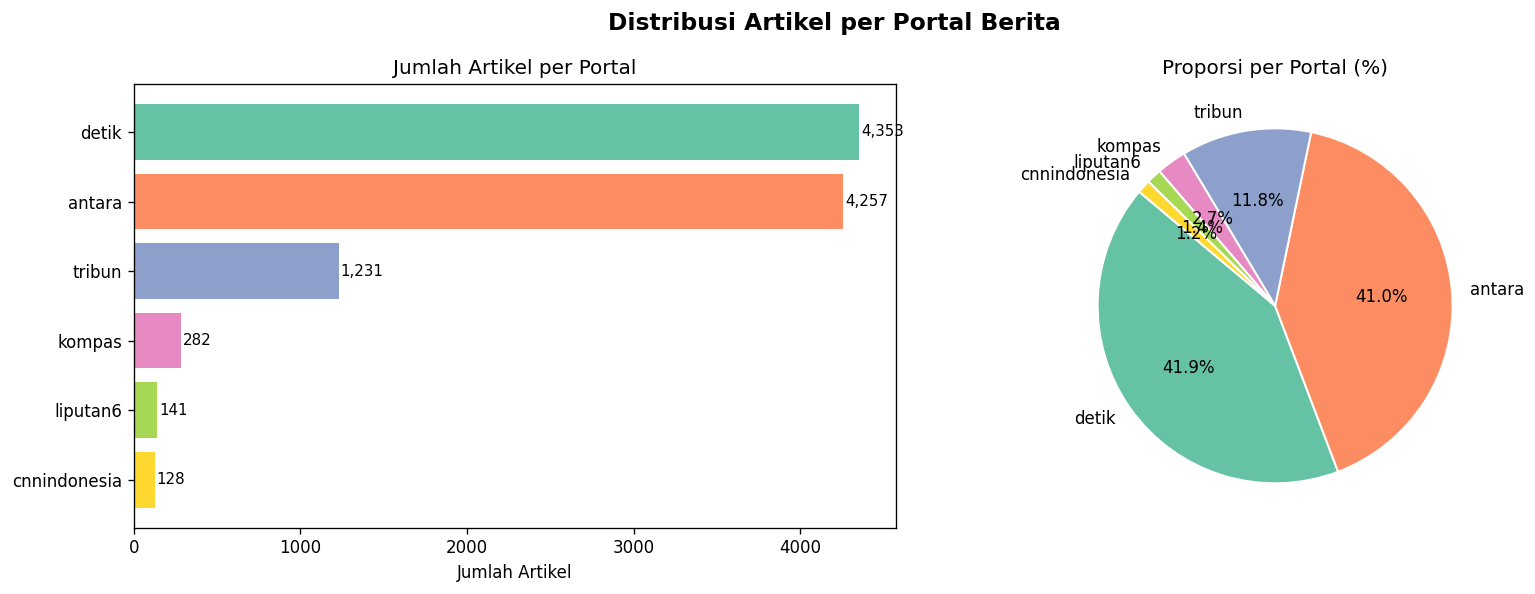

              jumlah
portal              
detik           4353
antara          4257
tribun          1231
kompas           282
liputan6         141
cnnindonesia     128


In [69]:
portal_counts = df['portal'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Artikel per Portal Berita', fontsize=14, fontweight='bold')

colors_portal = sns.color_palette(PALETTE, len(portal_counts))

# Bar chart
bars = axes[0].barh(portal_counts.index, portal_counts.values, color=colors_portal)
axes[0].set_xlabel('Jumlah Artikel')
axes[0].set_title('Jumlah Artikel per Portal')
for bar, val in zip(bars, portal_counts.values):
    axes[0].text(val + 10, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)
axes[0].invert_yaxis()

# Pie chart
axes[1].pie(portal_counts.values, labels=portal_counts.index, autopct='%1.1f%%',
            colors=colors_portal, startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.2))
axes[1].set_title('Proporsi per Portal (%)')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/plot_01_distribusi_portal.png', bbox_inches='tight')
plt.show()

print(portal_counts.to_frame('jumlah'))

### 2.3 Distribusi per Kategori

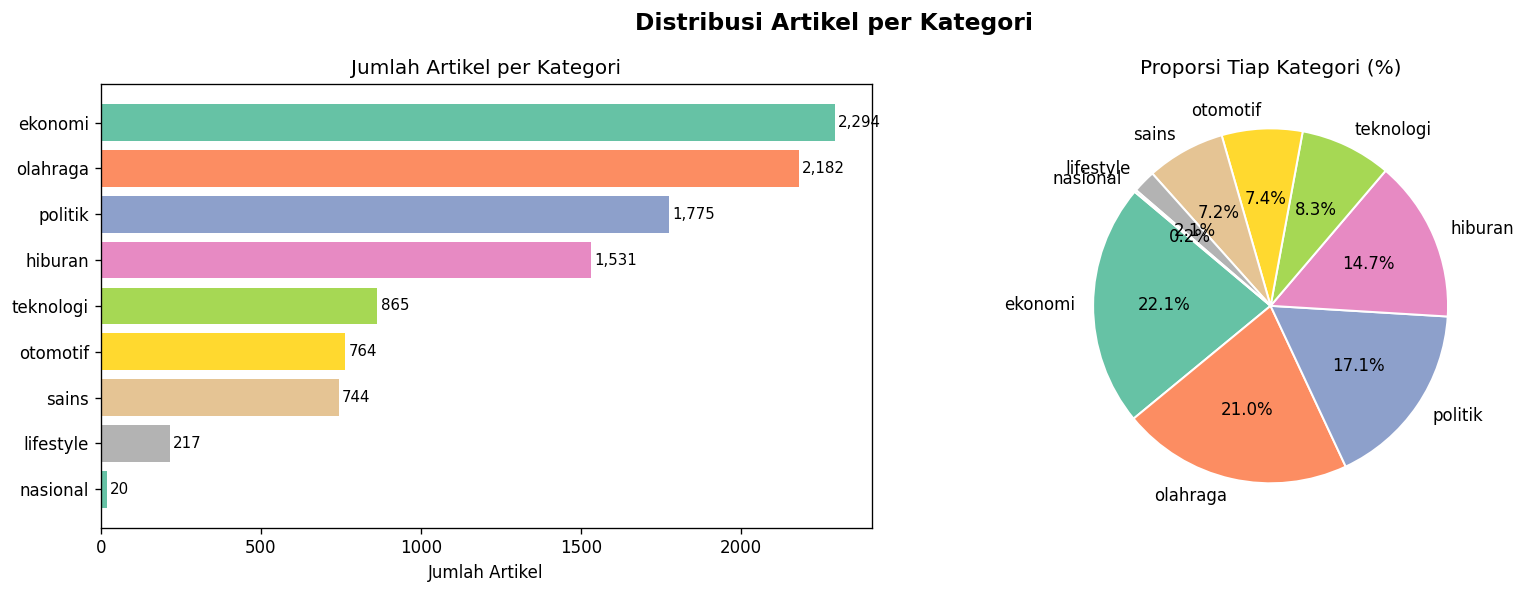

           jumlah
kategori         
ekonomi      2294
olahraga     2182
politik      1775
hiburan      1531
teknologi     865
otomotif      764
sains         744
lifestyle     217
nasional       20


In [70]:
kat_counts = df['kategori'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Artikel per Kategori', fontsize=14, fontweight='bold')

colors = sns.color_palette(PALETTE, len(kat_counts))

bars = axes[0].barh(kat_counts.index, kat_counts.values, color=colors)
axes[0].set_xlabel('Jumlah Artikel')
axes[0].set_title('Jumlah Artikel per Kategori')
for bar, val in zip(bars, kat_counts.values):
    axes[0].text(val + 10, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)
axes[0].invert_yaxis()

axes[1].pie(kat_counts.values, labels=kat_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.2))
axes[1].set_title('Proporsi Tiap Kategori (%)')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/plot_02_distribusi_kategori.png', bbox_inches='tight')
plt.show()

print(kat_counts.to_frame('jumlah'))

### 2.4 Heatmap: Distribusi Artikel per Kategori × Portal

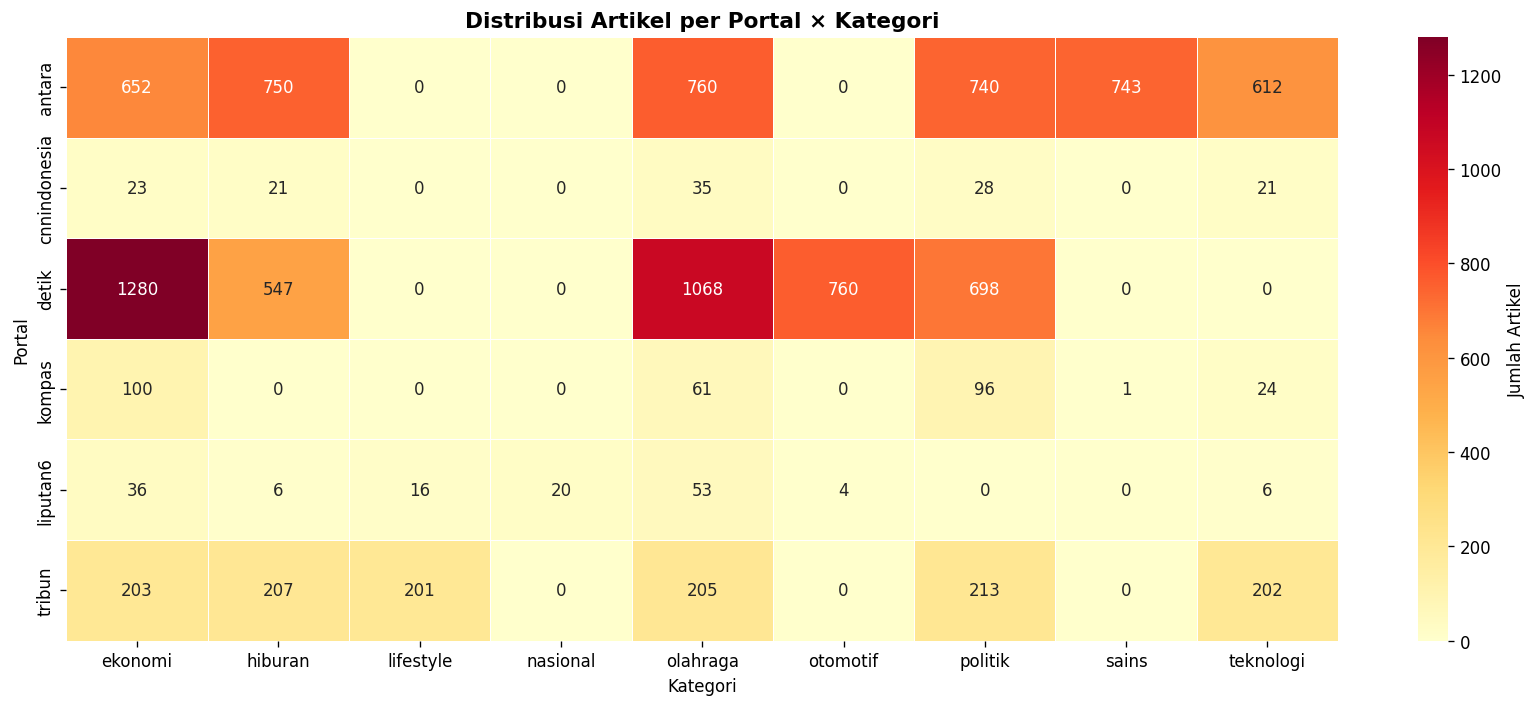


Crosstab Portal × Kategori:
kategori      ekonomi  hiburan  lifestyle  nasional  olahraga  otomotif  \
portal                                                                    
antara            652      750          0         0       760         0   
cnnindonesia       23       21          0         0        35         0   
detik            1280      547          0         0      1068       760   
kompas            100        0          0         0        61         0   
liputan6           36        6         16        20        53         4   
tribun            203      207        201         0       205         0   

kategori      politik  sains  teknologi  
portal                                   
antara            740    743        612  
cnnindonesia       28      0         21  
detik             698      0          0  
kompas             96      1         24  
liputan6            0      0          6  
tribun            213      0        202  


In [71]:
# Crosstab Portal vs Kategori — penting karena FP ini multi-sumber
crosstab = pd.crosstab(df['portal'], df['kategori'])

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Jumlah Artikel'})
ax.set_title('Distribusi Artikel per Portal × Kategori', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori')
ax.set_ylabel('Portal')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/plot_03_heatmap_portal_kategori.png', bbox_inches='tight')
plt.show()

print('\nCrosstab Portal × Kategori:')
print(crosstab)

### 2.5 Analisis Panjang Teks

=== STATISTIK PANJANG TEKS ===
       panjang_karakter  jumlah_kata
count           10392.0      10392.0
mean             2426.4        334.3
std              1190.4        160.4
min               150.0         19.0
25%              1819.0        255.0
50%              2343.0        323.0
75%              2925.5        399.0
max             55235.0       7722.0


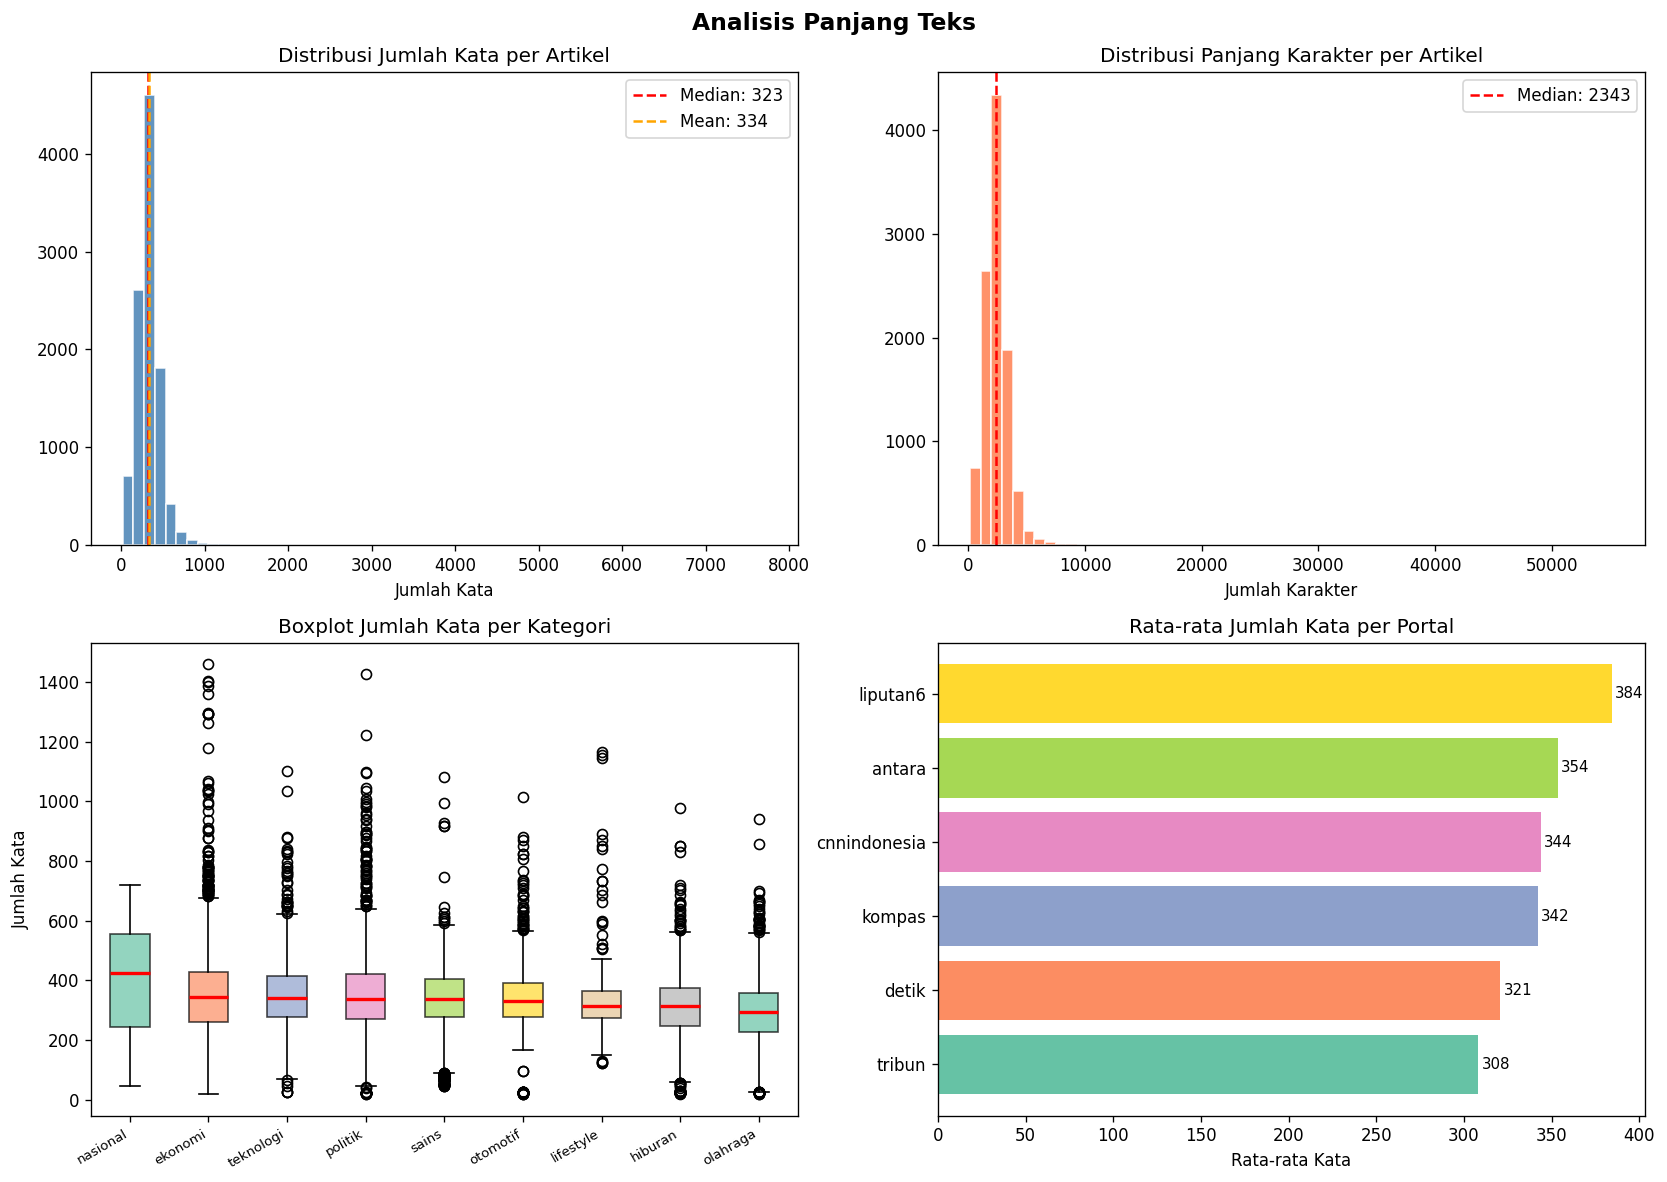


Rata-rata kata per kategori:
            mean  median  min   max
kategori                           
ekonomi    359.0   343.0   19  7722
hiburan    311.7   313.0   21   977
lifestyle  345.2   314.0  125  1166
nasional   389.0   426.5   46   719
olahraga   297.0   294.0   20   941
otomotif   346.1   330.5   20  1013
politik    356.4   339.0   19  1833
sains      320.7   339.0   47  1080
teknologi  355.5   340.0   26  1103

Rata-rata kata per portal:
               mean  median  min   max
portal                                
antara        353.6   355.0   26  1103
cnnindonesia  343.8   313.5  127   977
detik         320.6   296.0   19  7722
kompas        342.1   339.0   76   640
liputan6      384.2   340.0   46  1404
tribun        308.1   299.0   98  1144


In [72]:
df['panjang_karakter'] = df['isi'].astype(str).apply(len)
df['jumlah_kata']      = df['isi'].astype(str).apply(lambda x: len(x.split()))

print('=== STATISTIK PANJANG TEKS ===')
print(df[['panjang_karakter', 'jumlah_kata']].describe().round(1))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analisis Panjang Teks', fontsize=14, fontweight='bold')

# Histogram jumlah kata
axes[0,0].hist(df['jumlah_kata'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df['jumlah_kata'].median(), color='red',    linestyle='--',
                  label=f'Median: {df["jumlah_kata"].median():.0f}')
axes[0,0].axvline(df['jumlah_kata'].mean(),   color='orange', linestyle='--',
                  label=f'Mean: {df["jumlah_kata"].mean():.0f}')
axes[0,0].set_title('Distribusi Jumlah Kata per Artikel')
axes[0,0].set_xlabel('Jumlah Kata')
axes[0,0].legend()

# Histogram jumlah karakter
axes[0,1].hist(df['panjang_karakter'], bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[0,1].axvline(df['panjang_karakter'].median(), color='red', linestyle='--',
                  label=f'Median: {df["panjang_karakter"].median():.0f}')
axes[0,1].set_title('Distribusi Panjang Karakter per Artikel')
axes[0,1].set_xlabel('Jumlah Karakter')
axes[0,1].legend()

# Boxplot jumlah kata per kategori
df_vis    = df[df['jumlah_kata'] < 1500]
kat_order = df_vis.groupby('kategori')['jumlah_kata'].median().sort_values(ascending=False).index
data_box  = [df_vis[df_vis['kategori'] == k]['jumlah_kata'].values for k in kat_order]
bp = axes[1,0].boxplot(data_box, patch_artist=True,
                        medianprops=dict(color='red', linewidth=2))
colors2 = sns.color_palette(PALETTE, len(kat_order))
for patch, c in zip(bp['boxes'], colors2):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1,0].set_xticklabels(kat_order, rotation=30, ha='right', fontsize=8)
axes[1,0].set_title('Boxplot Jumlah Kata per Kategori')
axes[1,0].set_ylabel('Jumlah Kata')

# Rata-rata kata per portal
mean_kata_portal = df.groupby('portal')['jumlah_kata'].mean().sort_values()
colors3   = sns.color_palette(PALETTE, len(mean_kata_portal))
axes[1,1].barh(mean_kata_portal.index, mean_kata_portal.values, color=colors3)
axes[1,1].set_title('Rata-rata Jumlah Kata per Portal')
axes[1,1].set_xlabel('Rata-rata Kata')
for i, v in enumerate(mean_kata_portal.values):
    axes[1,1].text(v + 2, i, f'{v:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/plot_04_panjang_teks.png', bbox_inches='tight')
plt.show()

print('\nRata-rata kata per kategori:')
print(df.groupby('kategori')['jumlah_kata'].agg(['mean','median','min','max']).round(1))
print('\nRata-rata kata per portal:')
print(df.groupby('portal')['jumlah_kata'].agg(['mean','median','min','max']).round(1))

### 2.6 Identifikasi Noise & Masalah Data

In [73]:
print('=== [1] Noise scraping "SCROLL TO CONTINUE" ===')
mask_scroll = df['isi'].astype(str).str.contains('SCROLL TO CONTINUE', na=False)
print(f'Jumlah : {mask_scroll.sum()} ({mask_scroll.mean()*100:.1f}%)')
print()

print('=== [2] Artikel pendek (<50 kata) ===')
mask_pendek = df['jumlah_kata'] < 50
print(f'Jumlah : {mask_pendek.sum()}')
print(df[mask_pendek][['portal','kategori','judul','jumlah_kata']].head(5).to_string())
print()

print('=== [3] Artikel video ===')
mask_video = df['judul'].str.contains(r'^Video', case=False, regex=True, na=False)
print(f'Judul mulai "Video"  : {mask_video.sum()}')
print(f'Overlap pendek+video : {(mask_video & mask_pendek).sum()}')
print()

print('=== [4] Duplikat isi ===')
dup_isi = df['isi'].duplicated(keep=False)
print(f'Baris duplikat isi : {dup_isi.sum()}')
print()

print('=== [5] Kategori minoritas (<100 artikel) ===')
kat_kecil = kat_counts[kat_counts < 100]
print(kat_kecil)
print()

print('=== [6] Distribusi noise per portal ===')
noise_per_portal = df[mask_scroll].groupby('portal').size()
print(noise_per_portal)

print('\n=== RINGKASAN MASALAH DATA ===')
masalah = {
    'Noise SCROLL TO CONTINUE'    : mask_scroll.sum(),
    'Artikel pendek (<50 kata)'   : mask_pendek.sum(),
    'Duplikat isi'                : df['isi'].duplicated().sum(),
    'Kategori nasional (minoritas)': (df['kategori']=='nasional').sum(),
}
for k, v in masalah.items():
    print(f'  {k:<38} : {v:,}')

=== [1] Noise scraping "SCROLL TO CONTINUE" ===
Jumlah : 4174 (40.2%)

=== [2] Artikel pendek (<50 kata) ===
Jumlah : 198
   portal kategori                                                                            judul  jumlah_kata
18  detik  ekonomi  Teknologi dan Keringat Buruh Pelabuhan, Kunci Kelancaran Arus Logistik Nasional           21
25  detik  ekonomi                      Potret Toko Roti Rumahan Raih Kontrak Ekspor Maskapai Dunia           24
34  detik  ekonomi                Protes Nasional Lumpuhkan Pasokan, Pasar di Bolivia Nyaris Kosong           25
47  detik  ekonomi                           Lahan Pemakaman Disulap Jadi Lapak Jualan Hewan Kurban           21
98  detik  ekonomi                                            Limbah Buah Disulap Jadi Sabun Binatu           21

=== [3] Artikel video ===
Judul mulai "Video"  : 70
Overlap pendek+video : 28

=== [4] Duplikat isi ===
Baris duplikat isi : 345

=== [5] Kategori minoritas (<100 artikel) ===
kategori
nasional    20

### 2.7 Top-15 Kata per Kategori (Sebelum Preprocessing)

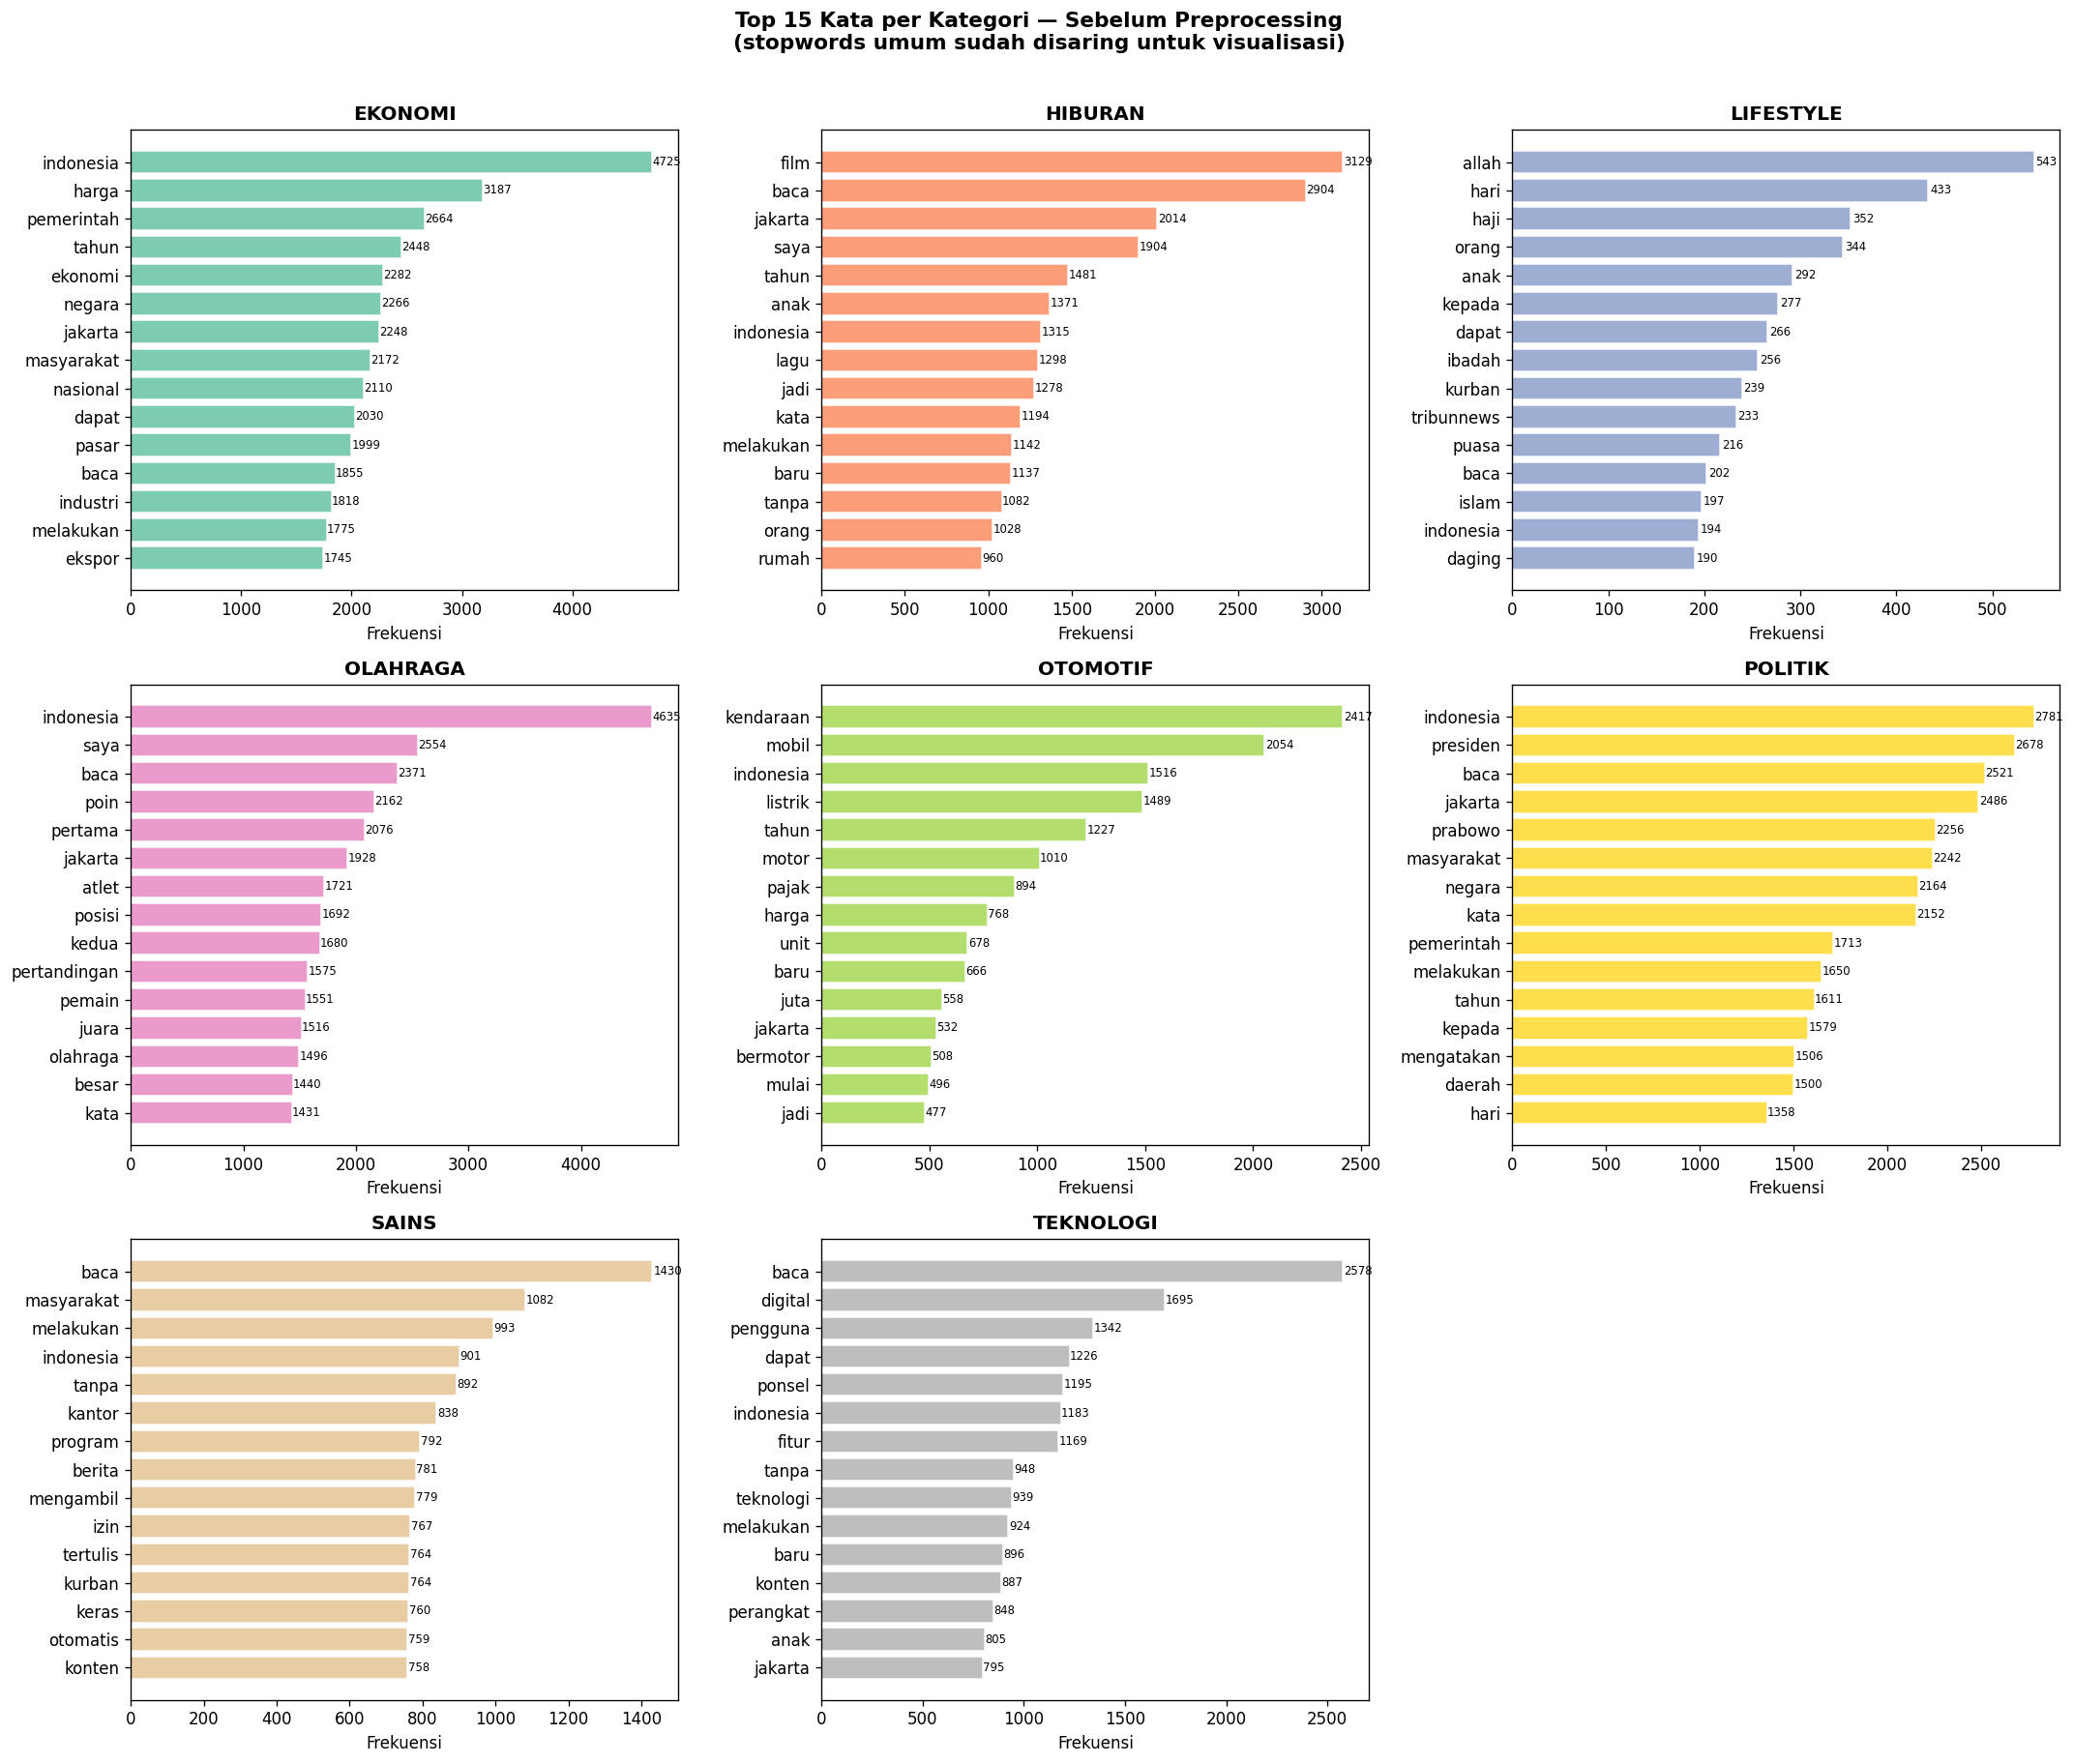

In [74]:
SW_VIS = {
    'yang','dan','ini','dari','dalam','dengan','untuk','juga','pada',
    'itu','atau','adalah','akan','ini','ada','bisa','tidak','ke','di',
    'the','oleh','sudah','saat','agar','jika','karena','menjadi','kita',
    'kami','mereka','harus','lebih','setelah','namun','sebagai','sehingga',
    'tersebut','bahwa','namun','seperti','antara','hingga','serta','pun',
    'advertisement', 'tetap', 'telah', 'para', 'bagi', 'hanya', 'satu',
    'banyak', 'secara', 'masih', 'melalui', 'terhadap', 'gambas'
}

def get_top_words_vis(texts, n=15, stopwords=SW_VIS):
    all_words = []
    for t in texts:
        t = re.sub(r'SCROLL TO CONTINUE WITH CONTENT', ' ', str(t))
        t = re.sub(r'http\S+', ' ', t.lower())
        t = re.sub(r'[^a-zA-Z\s]', ' ', t)
        all_words.extend([w for w in t.split() if len(w) >= 4 and w not in stopwords])
    return Counter(all_words).most_common(n)

kat_list = [k for k in sorted(df['kategori'].unique()) if k != 'nasional']
ncols    = 3
nrows    = (len(kat_list) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5))
axes = axes.flatten()

for i, kat in enumerate(kat_list):
    top    = get_top_words_vis(df[df['kategori'] == kat]['isi'], n=15)
    words  = [w for w, _ in top]
    counts = [c for _, c in top]
    color  = sns.color_palette(PALETTE, len(kat_list))[i]
    axes[i].barh(words[::-1], counts[::-1], color=color, alpha=0.85, edgecolor='white')
    axes[i].set_title(f'{kat.upper()}', fontweight='bold')
    axes[i].set_xlabel('Frekuensi')
    for bar, cnt in zip(axes[i].patches, counts[::-1]):
        axes[i].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                     str(cnt), va='center', fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Top 15 Kata per Kategori — Sebelum Preprocessing\n(stopwords umum sudah disaring untuk visualisasi)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/plot_05_topkata_raw.png', bbox_inches='tight')
plt.show()

### 2.8 Vocabulary Richness — STTR per Kategori

=== TYPE-TOKEN RATIO per KATEGORI ===
(STTR lebih fair — tidak terpengaruh ukuran corpus)
 kategori  n_artikel  total_token  vocab_unik  TTR (raw)   STTR
  hiburan       1531       452022       23580     0.0522 0.5079
lifestyle        217        71951        9219     0.1281 0.5018
 otomotif        764       244187       12615     0.0517 0.4954
    sains        744       225159       14109     0.0627 0.4943
 olahraga       2182       598176       19555     0.0327 0.4937
  politik       1775       598060       21914     0.0366 0.4888
  ekonomi       2294       767718       22498     0.0293 0.4839
teknologi        865       285943       13167     0.0460 0.4803
 nasional         20         7409        1821     0.2458 0.4441


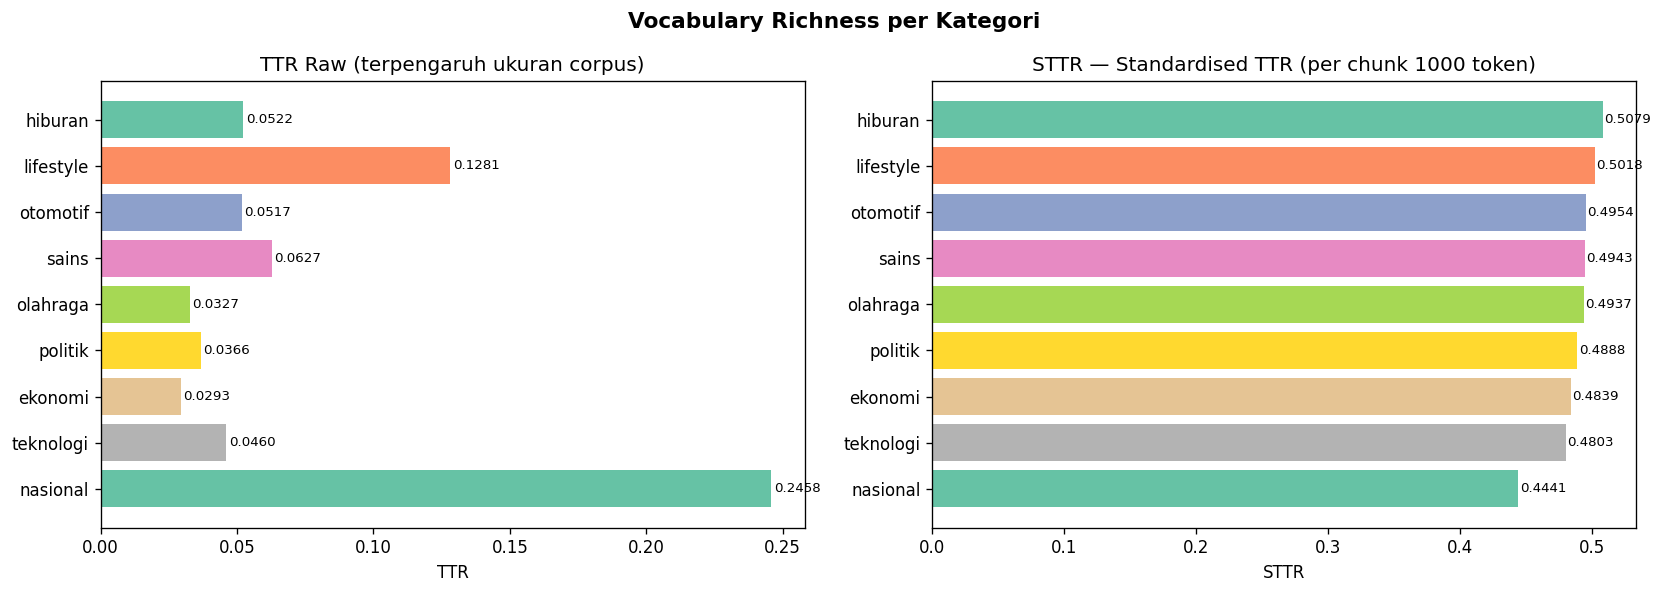

In [75]:
def hitung_sttr(texts, chunk_size=1000):
    """Standardised TTR — lebih fair untuk corpus berbeda ukuran."""
    all_words = []
    for t in texts:
        t = re.sub(r'[^a-zA-Z\s]', ' ', str(t).lower())
        all_words.extend([w for w in t.split() if w.isalpha() and len(w) > 2])

    if len(all_words) < chunk_size:
        unik  = len(set(all_words))
        total = len(all_words)
        return unik/total if total > 0 else 0, total, unik

    ttrs = []
    for start in range(0, len(all_words) - chunk_size + 1, chunk_size):
        chunk = all_words[start:start + chunk_size]
        ttrs.append(len(set(chunk)) / chunk_size)

    return np.mean(ttrs), len(all_words), len(set(all_words))

ttr_data = []
for kat in df['kategori'].unique():
    subset        = df[df['kategori'] == kat]['isi'].astype(str)
    sttr, total, unik = hitung_sttr(subset)
    ttr_raw       = unik / total if total > 0 else 0
    ttr_data.append({
        'kategori'   : kat,
        'n_artikel'  : len(subset),
        'total_token': total,
        'vocab_unik' : unik,
        'TTR (raw)'  : round(ttr_raw, 4),
        'STTR'       : round(sttr, 4)
    })

df_ttr = pd.DataFrame(ttr_data).sort_values('STTR', ascending=False)
print('=== TYPE-TOKEN RATIO per KATEGORI ===')
print('(STTR lebih fair — tidak terpengaruh ukuran corpus)')
print(df_ttr.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Vocabulary Richness per Kategori', fontsize=13, fontweight='bold')

colors4 = sns.color_palette(PALETTE, len(df_ttr))
axes[0].barh(df_ttr['kategori'], df_ttr['TTR (raw)'], color=colors4)
axes[0].set_title('TTR Raw (terpengaruh ukuran corpus)')
axes[0].set_xlabel('TTR')
axes[0].invert_yaxis()
for i, v in enumerate(df_ttr['TTR (raw)']):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)

df_ttr_s = df_ttr.sort_values('STTR', ascending=False)
axes[1].barh(df_ttr_s['kategori'], df_ttr_s['STTR'], color=colors4)
axes[1].set_title('STTR — Standardised TTR (per chunk 1000 token)')
axes[1].set_xlabel('STTR')
axes[1].invert_yaxis()
for i, v in enumerate(df_ttr_s['STTR']):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/plot_06_TTR.png', bbox_inches='tight')
plt.show()

---
## 3. Preprocessing

### 3.1 Drop Duplikat, Artikel Pendek & Kategori Minoritas

In [76]:
n_awal = len(df)
print(f'Data awal : {n_awal:,}')

# 1. Drop duplikat isi
df_clean = df.drop_duplicates(subset=['isi'], keep='first').copy()
print(f'Setelah drop duplikat isi        : {len(df_clean):,} (hapus {n_awal - len(df_clean)})')

# 2. Drop artikel sangat pendek (<50 kata)
n2 = len(df_clean)
df_clean = df_clean[df_clean['jumlah_kata'] >= 50].copy()
print(f'Setelah drop artikel pendek      : {len(df_clean):,} (hapus {n2 - len(df_clean)})')

# 3. Drop kategori 'nasional' — hanya 20 artikel, terlalu sedikit untuk topic model
n3 = len(df_clean)
df_clean = df_clean[df_clean['kategori'] != 'nasional'].copy()
print(f'Setelah drop kategori nasional   : {len(df_clean):,} (hapus {n3 - len(df_clean)})')

df_clean.reset_index(drop=True, inplace=True)
print(f'\nTotal dihapus : {n_awal - len(df_clean):,}')
print(f'Data tersisa  : {len(df_clean):,}')
print()
print('Distribusi kategori setelah cleaning awal:')
print(df_clean['kategori'].value_counts())
print()
print('Distribusi portal setelah cleaning awal:')
print(df_clean['portal'].value_counts())

Data awal : 10,392
Setelah drop duplikat isi        : 10,193 (hapus 199)
Setelah drop artikel pendek      : 10,009 (hapus 184)
Setelah drop kategori nasional   : 9,990 (hapus 19)

Total dihapus : 402
Data tersisa  : 9,990

Distribusi kategori setelah cleaning awal:
kategori
ekonomi      2210
olahraga     2071
politik      1736
hiburan      1459
teknologi     846
otomotif      740
sains         712
lifestyle     216
Name: count, dtype: int64

Distribusi portal setelah cleaning awal:
portal
detik           4150
antara          4082
tribun          1231
kompas           282
cnnindonesia     128
liputan6         117
Name: count, dtype: int64


### 3.2 Load Kamus Normalisasi Slang/Alay

In [77]:
SLANG_URL = 'https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv'

try:
    df_slang   = pd.read_csv(SLANG_URL)
    slang_dict = dict(zip(
        df_slang.iloc[:, 0].str.lower().str.strip(),
        df_slang.iloc[:, 1].str.lower().str.strip()
    ))
    print(f'✅ Kamus slang berhasil diload: {len(slang_dict):,} entri')
    print(df_slang.head(5))
except Exception as e:
    print(f'⚠ Gagal load kamus slang: {e}')
    slang_dict = {
        'yg':'yang','dgn':'dengan','utk':'untuk','krn':'karena',
        'tdk':'tidak','jg':'juga','sdh':'sudah','blm':'belum',
        'thn':'tahun','org':'orang','dg':'dengan','pd':'pada',
        'tp':'tapi','kpd':'kepada','sbg':'sebagai',
        'nggak':'tidak','gak':'tidak','ga':'tidak',
        'udah':'sudah','udh':'sudah','aja':'saja',
        'kalo':'kalau','klo':'kalau','gmn':'bagaimana',
        'emang':'memang','kayak':'seperti',
    }
    print(f'Menggunakan kamus manual: {len(slang_dict)} entri')

print(f'\nTotal entri kamus: {len(slang_dict):,}')

✅ Kamus slang berhasil diload: 4,330 entri
     slang    formal  In-dictionary  \
0     woww       wow              1   
1    aminn      amin              1   
2      met   selamat              1   
3   netaas   menetas              1   
4  keberpa  keberapa              0   

                                             context  category1 category2  \
0                                                wow   elongasi         0   
1  Selamat ulang tahun kakak tulus semoga panjang...   elongasi         0   
2  Met hari netaas kak!? Wish you all the best @t...  abreviasi         0   
3  Met hari netaas kak!? Wish you all the best @t...   afiksasi  elongasi   
4                           Birthday yg keberpa kak?  abreviasi         0   

  category3  
0         0  
1         0  
2         0  
3         0  
4         0  

Total entri kamus: 4,330


### 3.3 Definisi Stopwords

In [78]:
swf          = StopWordRemoverFactory()
stopword_set = set(swf.get_stop_words())

custom_stopwords = {
    # Noise scraping
    'scroll', 'continue', 'content', 'advertisement', 'iklan',
    # Nama media / portal
    'detik', 'com', 'liputan', 'kompas', 'tribun', 'cnbc',
    'reuters', 'antara', 'tempo', 'republika', 'okezone',
    'cnnindonesia', 'cnn',
    # Kata umum berita — tidak informatif untuk topic model
    'kata', 'ujar', 'tutur', 'ungkap', 'jelas', 'sebut', 'ucap',
    'tambah', 'sampaikan', 'bilang', 'baca', 'foto', 'video',
    'simak', 'berita', 'artikel', 'terkait', 'terkini', 'terbaru',
    # Kata generic yang muncul di semua kategori
    'indonesia', 'telah', 'para', 'bagi', 'hanya', 'secara',
    'melalui', 'terhadap', 'masih', 'tetap', 'gambas',
    'serta', 'namun', 'bahwa', 'tersebut', 'hingga',
    # HTML / teknis
    'nbsp', 'amp', 'quot', 'http', 'https', 'www',
    # Angka sebagai kata
    'satu', 'dua', 'tiga', 'empat', 'lima',
    'enam', 'tujuh', 'delapan', 'sembilan', 'sepuluh',
}
stopword_set.update(custom_stopwords)

print(f'Stopwords Sastrawi      : {len(swf.get_stop_words())}')
print(f'Custom stopwords        : {len(custom_stopwords)}')
print(f'Total stopwords gabungan: {len(stopword_set)}')

Stopwords Sastrawi      : 809
Custom stopwords        : 69
Total stopwords gabungan: 849


### 3.4 Fungsi Preprocessing Pipeline

In [79]:
def step1_clean_text(text):
    """
    Step 1 — Text Cleaning:
    Hapus noise scraping, lowercase, URL, HTML entity,
    angka, tanda baca, normalize whitespace.
    """
    text = str(text)
    # Sisipkan spasi sebelum huruf kapital yang menempel ke huruf kecil
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)
    # Noise scraping
    text = re.sub(r'SCROLL TO CONTINUE WITH CONTENT', ' ', text)
    text = re.sub(r'ADVERTISEMENT', ' ', text)
    text = re.sub(r'Advertisement', ' ', text)
    # Lowercase
    text = text.lower()
    # URL
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    # HTML entity & tag
    text = re.sub(r'&[a-z]+;', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    # Angka standalone
    text = re.sub(r'\b\d+\b', ' ', text)
    # Token yang mengandung angka
    text = re.sub(r'\b\w*\d\w*\b', ' ', text)
    # Tanda baca & underscore
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'_', ' ', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def step2_normalize(text, kamus=slang_dict):
    """
    Step 2 — Normalisasi:
    Karakter berulang → 1 karakter, baru lookup kamus slang.
    """
    text   = re.sub(r'(.)\1{2,}', r'\1', text)
    tokens = text.split()
    tokens = [kamus.get(w, w) for w in tokens]
    return ' '.join(tokens)


def step3_remove_stopwords(text, sw_set=stopword_set, min_len=3):
    """
    Step 3 — Stopword Removal:
    Hapus stopwords, kata pendek, dan sisa token yang mengandung angka.
    """
    tokens = text.split()
    tokens = [
        w for w in tokens
        if w not in sw_set
        and len(w) >= min_len
        and not any(c.isdigit() for c in w)
    ]
    return ' '.join(tokens)


# Inisialisasi stemmer Sastrawi
sf      = StemmerFactory()
stemmer = sf.create_stemmer()

# Protected words: istilah teknis yang sering salah di-stem Sastrawi
PROTECTED = {
    # Ekonomi
    'inflasi', 'deflasi', 'investasi', 'inovasi', 'regulasi', 'legislasi',
    'korupsi', 'koalisi', 'oposisi', 'transformasi', 'digitalisasi',
    # Kesehatan
    'pandemi', 'epidemi', 'vaksin', 'vaksinasi', 'kolesterol',
    'hipertensi', 'diabetes', 'protein', 'kalori',
    # Teknologi
    'spesifikasi', 'transmisi', 'emisi', 'navigasi', 'turbo',
    # Olahraga
    'atlet', 'stadion', 'sponsor',
    # Politik
    'parlemen',
}

def step4_stem(text):
    """
    Step 4 — Stemming (Sastrawi):
    Protected words dilewati supaya tidak over-stemmed.
    Corpus ini digunakan untuk LDA/NMF.
    Corpus BERT gunakan teks_nostop (tanpa stemming).
    """
    tokens = text.split()
    result = [
        w if w in PROTECTED else stemmer.stem(w)
        for w in tokens
    ]
    return ' '.join(result)


# Tes pipeline pada 3 sampel
print('=== TES PIPELINE (3 SAMPEL) ===')
for _, row in df_clean.sample(3, random_state=42).iterrows():
    teks = row['isi']
    s1   = step1_clean_text(teks)
    s2   = step2_normalize(s1)
    s3   = step3_remove_stopwords(s2)
    s4   = step4_stem(s3)
    print(f"\n[{row['portal'].upper()} | {row['kategori'].upper()}] {row['judul'][:55]}")
    print(f"  Original  : {teks[:100].strip()}...")
    print(f"  S1 Clean  : {s1[:100]}...")
    print(f"  S2 Norm   : {s2[:100]}...")
    print(f"  S3 NoStop : {s3[:100]}...")
    print(f"  S4 Stem   : {s4[:100]}...")

=== TES PIPELINE (3 SAMPEL) ===

[ANTARA | OLAHRAGA] Veda Ega tetap di lima besar klasemen usai finis P8 di 
  Original  : Jakarta (ANTARA) - Pembalap Indonesia Veda Ega Pratama masih berada di posisi lima besar klasemen se...
  S1 Clean  : jakarta antara pembalap indonesia veda ega pratama masih berada di posisi lima besar klasemen sement...
  S2 Norm   : jakarta antara pembalap indonesia veda ega pratama masih berada di posisi lima besar klasemen sement...
  S3 NoStop : jakarta pembalap veda ega pratama posisi klasemen kejuaraan dunia finis posisi kedelapan putaran kee...
  S4 Stem   : jakarta balap veda ega pratama posisi klasemen juara dunia finis posisi delap putar enam catalunya c...

[DETIK | EKONOMI] Beli AC Split 1PK di Transmart Full Day Sale Diskonnya 
  Original  : Transmart kembali menggelar program belanja hemat Full Day Sale pada Minggu, 17 Mei 2026 besok. Mula...
  S1 Clean  : transmart kembali menggelar program belanja hemat full day sale pada minggu mei besok mulai to

### 3.5 Terapkan Step 1–3

In [80]:
print('Step 1/3: Text Cleaning...')
df_clean['teks_clean'] = df_clean['isi'].progress_apply(step1_clean_text)

print('Step 2/3: Normalisasi slang...')
df_clean['teks_norm'] = df_clean['teks_clean'].progress_apply(step2_normalize)

print('Step 3/3: Remove stopwords...')
df_clean['teks_nostop'] = df_clean['teks_norm'].progress_apply(step3_remove_stopwords)

df_clean['kata_clean']  = df_clean['teks_clean'].apply(lambda x: len(x.split()))
df_clean['kata_nostop'] = df_clean['teks_nostop'].apply(lambda x: len(x.split()))

print('\n✅ Step 1–3 selesai')
print(df_clean[['jumlah_kata', 'kata_clean', 'kata_nostop']].describe().round(1))

print(f'\nDokumen teks_nostop < 20 kata : {(df_clean["kata_nostop"] < 20).sum()}')

Step 1/3: Text Cleaning...


  0%|          | 0/9990 [00:00<?, ?it/s]

Step 2/3: Normalisasi slang...


  0%|          | 0/9990 [00:00<?, ?it/s]

Step 3/3: Remove stopwords...


  0%|          | 0/9990 [00:00<?, ?it/s]


✅ Step 1–3 selesai
       jumlah_kata  kata_clean  kata_nostop
count       9990.0      9990.0       9990.0
mean         340.2       332.0        194.1
std          156.3       156.4         89.9
min           50.0        47.0         25.0
25%          260.0       251.0        142.0
50%          326.0       318.0        186.0
75%          400.0       392.0        231.0
max         7722.0      7851.0       3766.0

Dokumen teks_nostop < 20 kata : 0


### 3.6 Step 4 — Stemming

In [81]:
# Simpan checkpoint sebelum stemming
CKPT_PATH = f'{SAVE_DIR}/checkpoint_sebelum_stem.pkl'
df_clean.to_pickle(CKPT_PATH)
print(f'✅ Checkpoint tersimpan: {CKPT_PATH}')

# Jika session putus, uncomment untuk lanjut dari checkpoint:
# df_clean = pd.read_pickle(CKPT_PATH)

print('\nStemming... (estimasi 15–30 menit di Colab)')
df_clean['teks_stem'] = df_clean['teks_nostop'].progress_apply(step4_stem)
df_clean['kata_stem'] = df_clean['teks_stem'].apply(lambda x: len(x.split()))

print('\n✅ Stemming selesai!')
print(df_clean[['kata_nostop', 'kata_stem']].describe().round(1))

# Verifikasi
contoh_nostop = df_clean['teks_nostop'].iloc[0][:60]
contoh_stem   = df_clean['teks_stem'].iloc[0][:60]
print(f'\nteks_nostop : {contoh_nostop}')
print(f'teks_stem   : {contoh_stem}')
print(f'Identik     : {contoh_nostop == contoh_stem}')

✅ Checkpoint tersimpan: /content/drive/MyDrive/TextMining/FP_TopicModelling/checkpoint_sebelum_stem.pkl

Stemming... (estimasi 15–30 menit di Colab)


  0%|          | 0/9990 [00:00<?, ?it/s]


✅ Stemming selesai!
       kata_nostop  kata_stem
count       9990.0     9990.0
mean         194.1      194.2
std           89.9       90.0
min           25.0       25.0
25%          142.0      142.0
50%          186.0      186.0
75%          231.0      231.0
max         3766.0     3766.0

teks_nostop : vktr teknologi mobilitas tbk vktr emiten kendaraan listrik k
teks_stem   : vktr teknologi mobilitas tbk vktr emiten kendara listrik kom
Identik     : False


### 3.7 Filter Teks Terlalu Pendek Setelah Preprocessing

In [82]:
n_sbl = len(df_clean)

df_clean = df_clean[df_clean['kata_nostop'] >= 20].copy()
df_clean.reset_index(drop=True, inplace=True)

print(f'Sebelum filter : {n_sbl:,}')
print(f'Setelah filter : {len(df_clean):,} (hapus {n_sbl - len(df_clean)})')
print()
print('Distribusi kategori final:')
print(df_clean['kategori'].value_counts())
print()
print('Distribusi portal final:')
print(df_clean['portal'].value_counts())

print(f'\nVerifikasi:')
print(f'  Semua dokumen kata_nostop >= 20 : {(df_clean["kata_nostop"] >= 20).all()}')
print(f'  Semua dokumen kata_stem >= 20   : {(df_clean["kata_stem"] >= 20).all()}')
print(f'  Jumlah dokumen                  : {len(df_clean)} dokumen')

Sebelum filter : 9,990
Setelah filter : 9,990 (hapus 0)

Distribusi kategori final:
kategori
ekonomi      2210
olahraga     2071
politik      1736
hiburan      1459
teknologi     846
otomotif      740
sains         712
lifestyle     216
Name: count, dtype: int64

Distribusi portal final:
portal
detik           4150
antara          4082
tribun          1231
kompas           282
cnnindonesia     128
liputan6         117
Name: count, dtype: int64

Verifikasi:
  Semua dokumen kata_nostop >= 20 : True
  Semua dokumen kata_stem >= 20   : True
  Jumlah dokumen                  : 9990 dokumen


---
## 4. Post-Preprocessing EDA

### 4.1 Perbandingan Panjang Teks per Tahap

=== RATA-RATA JUMLAH KATA PER TAHAP ===
  Original             mean=340  median=326  (reduksi 0.0%)
  After Clean          mean=332  median=318  (reduksi 2.4%)
  After Stopword       mean=194  median=186  (reduksi 42.9%)
  After Stem           mean=194  median=186  (reduksi 42.9%)


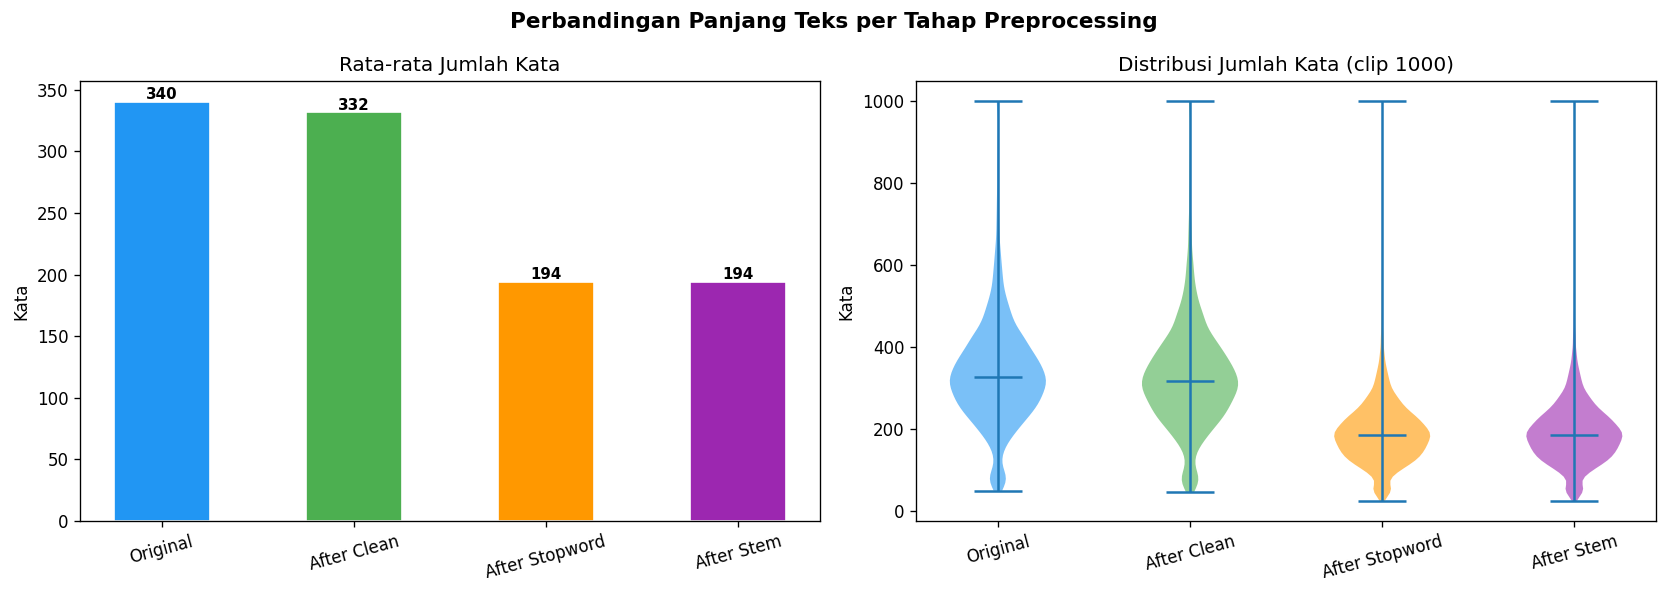

In [83]:
tahap   = ['Original', 'After Clean', 'After Stopword', 'After Stem']
kolom   = ['jumlah_kata', 'kata_clean', 'kata_nostop', 'kata_stem']
means   = [df_clean[k].mean() for k in kolom]
medians = [df_clean[k].median() for k in kolom]

print('=== RATA-RATA JUMLAH KATA PER TAHAP ===')
for t, m, md in zip(tahap, means, medians):
    reduksi = (1 - m / means[0]) * 100
    print(f'  {t:<20} mean={m:.0f}  median={md:.0f}  (reduksi {reduksi:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Perbandingan Panjang Teks per Tahap Preprocessing', fontsize=13, fontweight='bold')

colors5 = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

bars4 = axes[0].bar(tahap, means, color=colors5, edgecolor='white', width=0.5)
for bar, val in zip(bars4, means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val:.0f}', ha='center', fontweight='bold', fontsize=9)
axes[0].set_title('Rata-rata Jumlah Kata')
axes[0].set_ylabel('Kata')
axes[0].tick_params(axis='x', rotation=15)

data_violin = [df_clean[k].clip(upper=1000).values for k in kolom]
vp = axes[1].violinplot(data_violin, positions=range(len(tahap)), showmedians=True)
for body, c in zip(vp['bodies'], colors5):
    body.set_facecolor(c); body.set_alpha(0.6)
axes[1].set_xticks(range(len(tahap)))
axes[1].set_xticklabels(tahap, rotation=15)
axes[1].set_title('Distribusi Jumlah Kata (clip 1000)')
axes[1].set_ylabel('Kata')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/plot_07_perbandingan_tahap.png', bbox_inches='tight')
plt.show()

### 4.2 Distribusi Kategori & Portal Final

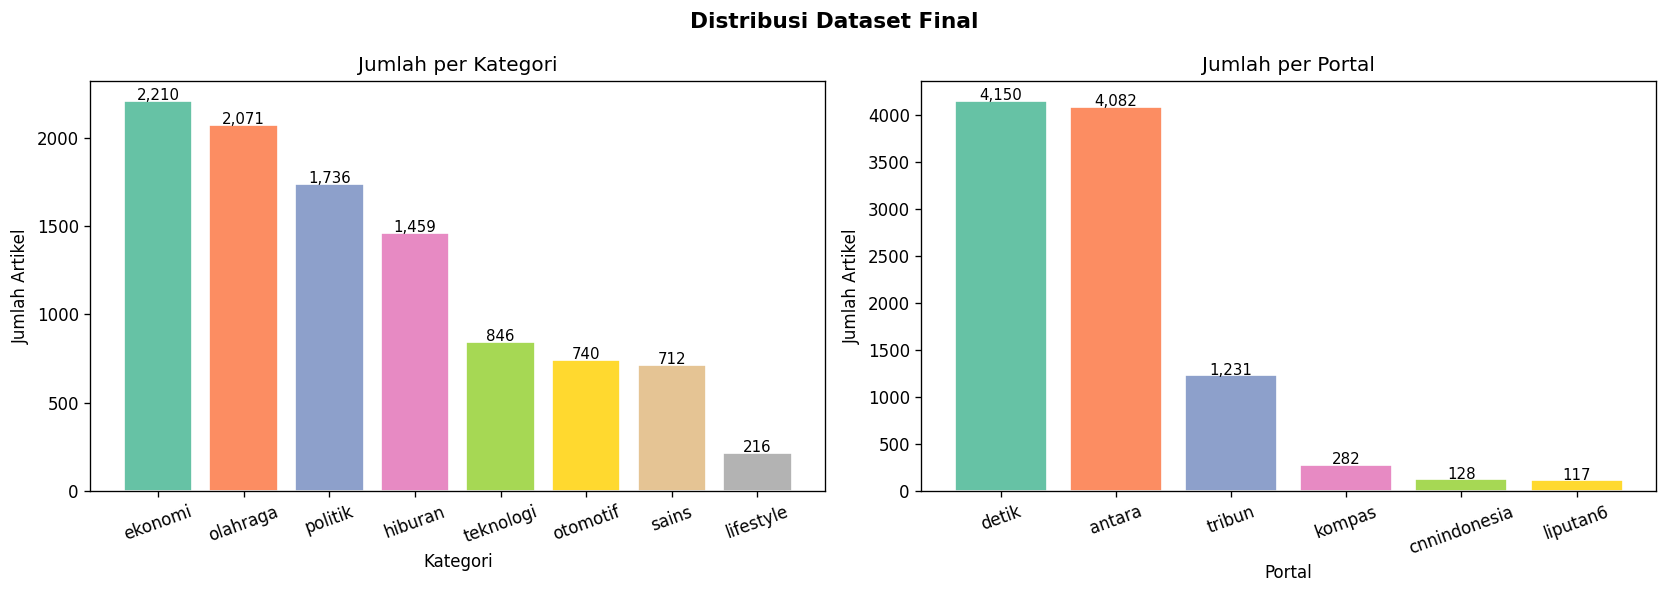

Kategori final:
           jumlah
kategori         
ekonomi      2210
olahraga     2071
politik      1736
hiburan      1459
teknologi     846
otomotif      740
sains         712
lifestyle     216

Portal final:
              jumlah
portal              
detik           4150
antara          4082
tribun          1231
kompas           282
cnnindonesia     128
liputan6         117


In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Dataset Final', fontsize=13, fontweight='bold')

kat_final    = df_clean['kategori'].value_counts()
portal_final = df_clean['portal'].value_counts()

colors6a = sns.color_palette(PALETTE, len(kat_final))
bars5a = axes[0].bar(kat_final.index, kat_final.values, color=colors6a, edgecolor='white')
for bar, val in zip(bars5a, kat_final.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:,}', ha='center', fontsize=9)
axes[0].set_title('Jumlah per Kategori')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah Artikel')
axes[0].tick_params(axis='x', rotation=20)

colors6b = sns.color_palette(PALETTE, len(portal_final))
bars5b = axes[1].bar(portal_final.index, portal_final.values, color=colors6b, edgecolor='white')
for bar, val in zip(bars5b, portal_final.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val:,}', ha='center', fontsize=9)
axes[1].set_title('Jumlah per Portal')
axes[1].set_xlabel('Portal')
axes[1].set_ylabel('Jumlah Artikel')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/plot_08_distribusi_final.png', bbox_inches='tight')
plt.show()

print('Kategori final:')
print(kat_final.to_frame('jumlah'))
print('\nPortal final:')
print(portal_final.to_frame('jumlah'))

### 4.3 WordCloud per Kategori (Teks Stemmed)

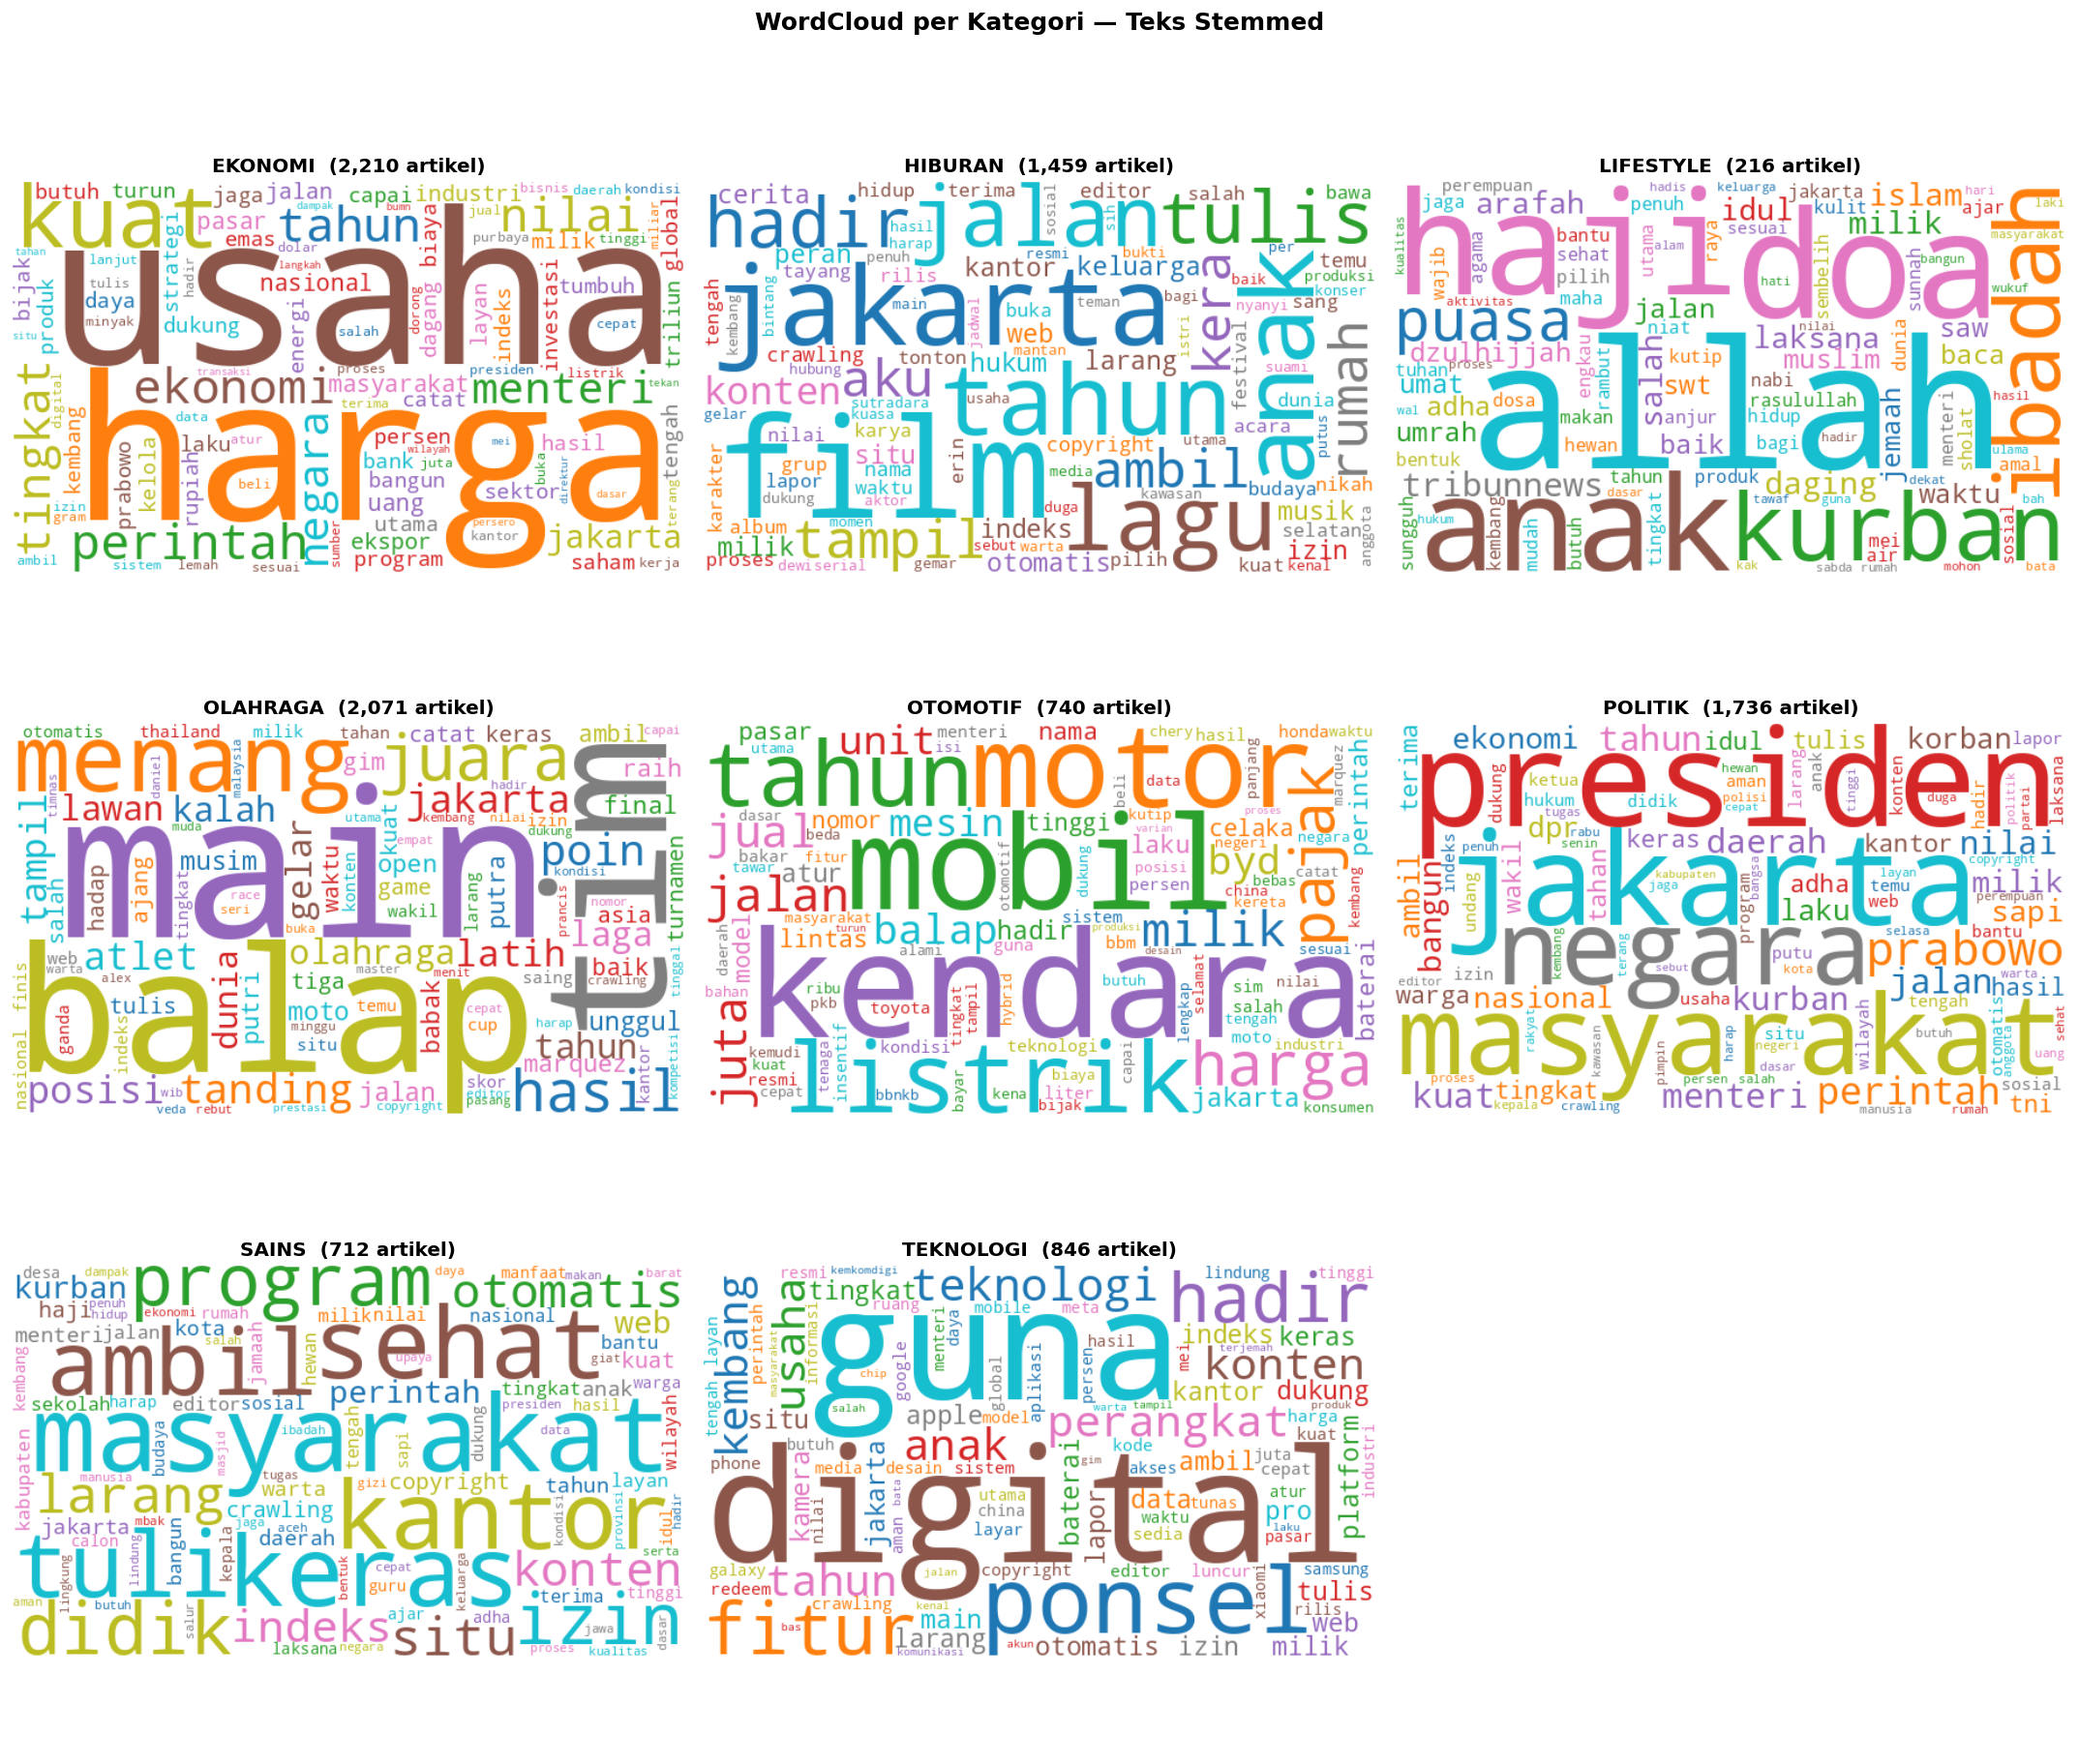

In [85]:
kat_wc = sorted(df_clean['kategori'].unique())
ncols  = 3
nrows  = (len(kat_wc) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5))
axes = axes.flatten()

for i, kat in enumerate(kat_wc):
    teks_gabung = ' '.join(df_clean[df_clean['kategori'] == kat]['teks_stem'].tolist())
    if not teks_gabung.strip():
        continue
    wc = WordCloud(
        width=600, height=350, background_color='white',
        max_words=100, colormap='tab10', collocations=False
    ).generate(teks_gabung)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    n_art = df_clean[df_clean['kategori'] == kat].shape[0]
    axes[i].set_title(f'{kat.upper()}  ({n_art:,} artikel)', fontweight='bold', fontsize=12)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('WordCloud per Kategori — Teks Stemmed', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/plot_09_wordcloud.png', bbox_inches='tight')
plt.show()

### 4.4 Top 15 Kata per Kategori (Setelah Preprocessing)

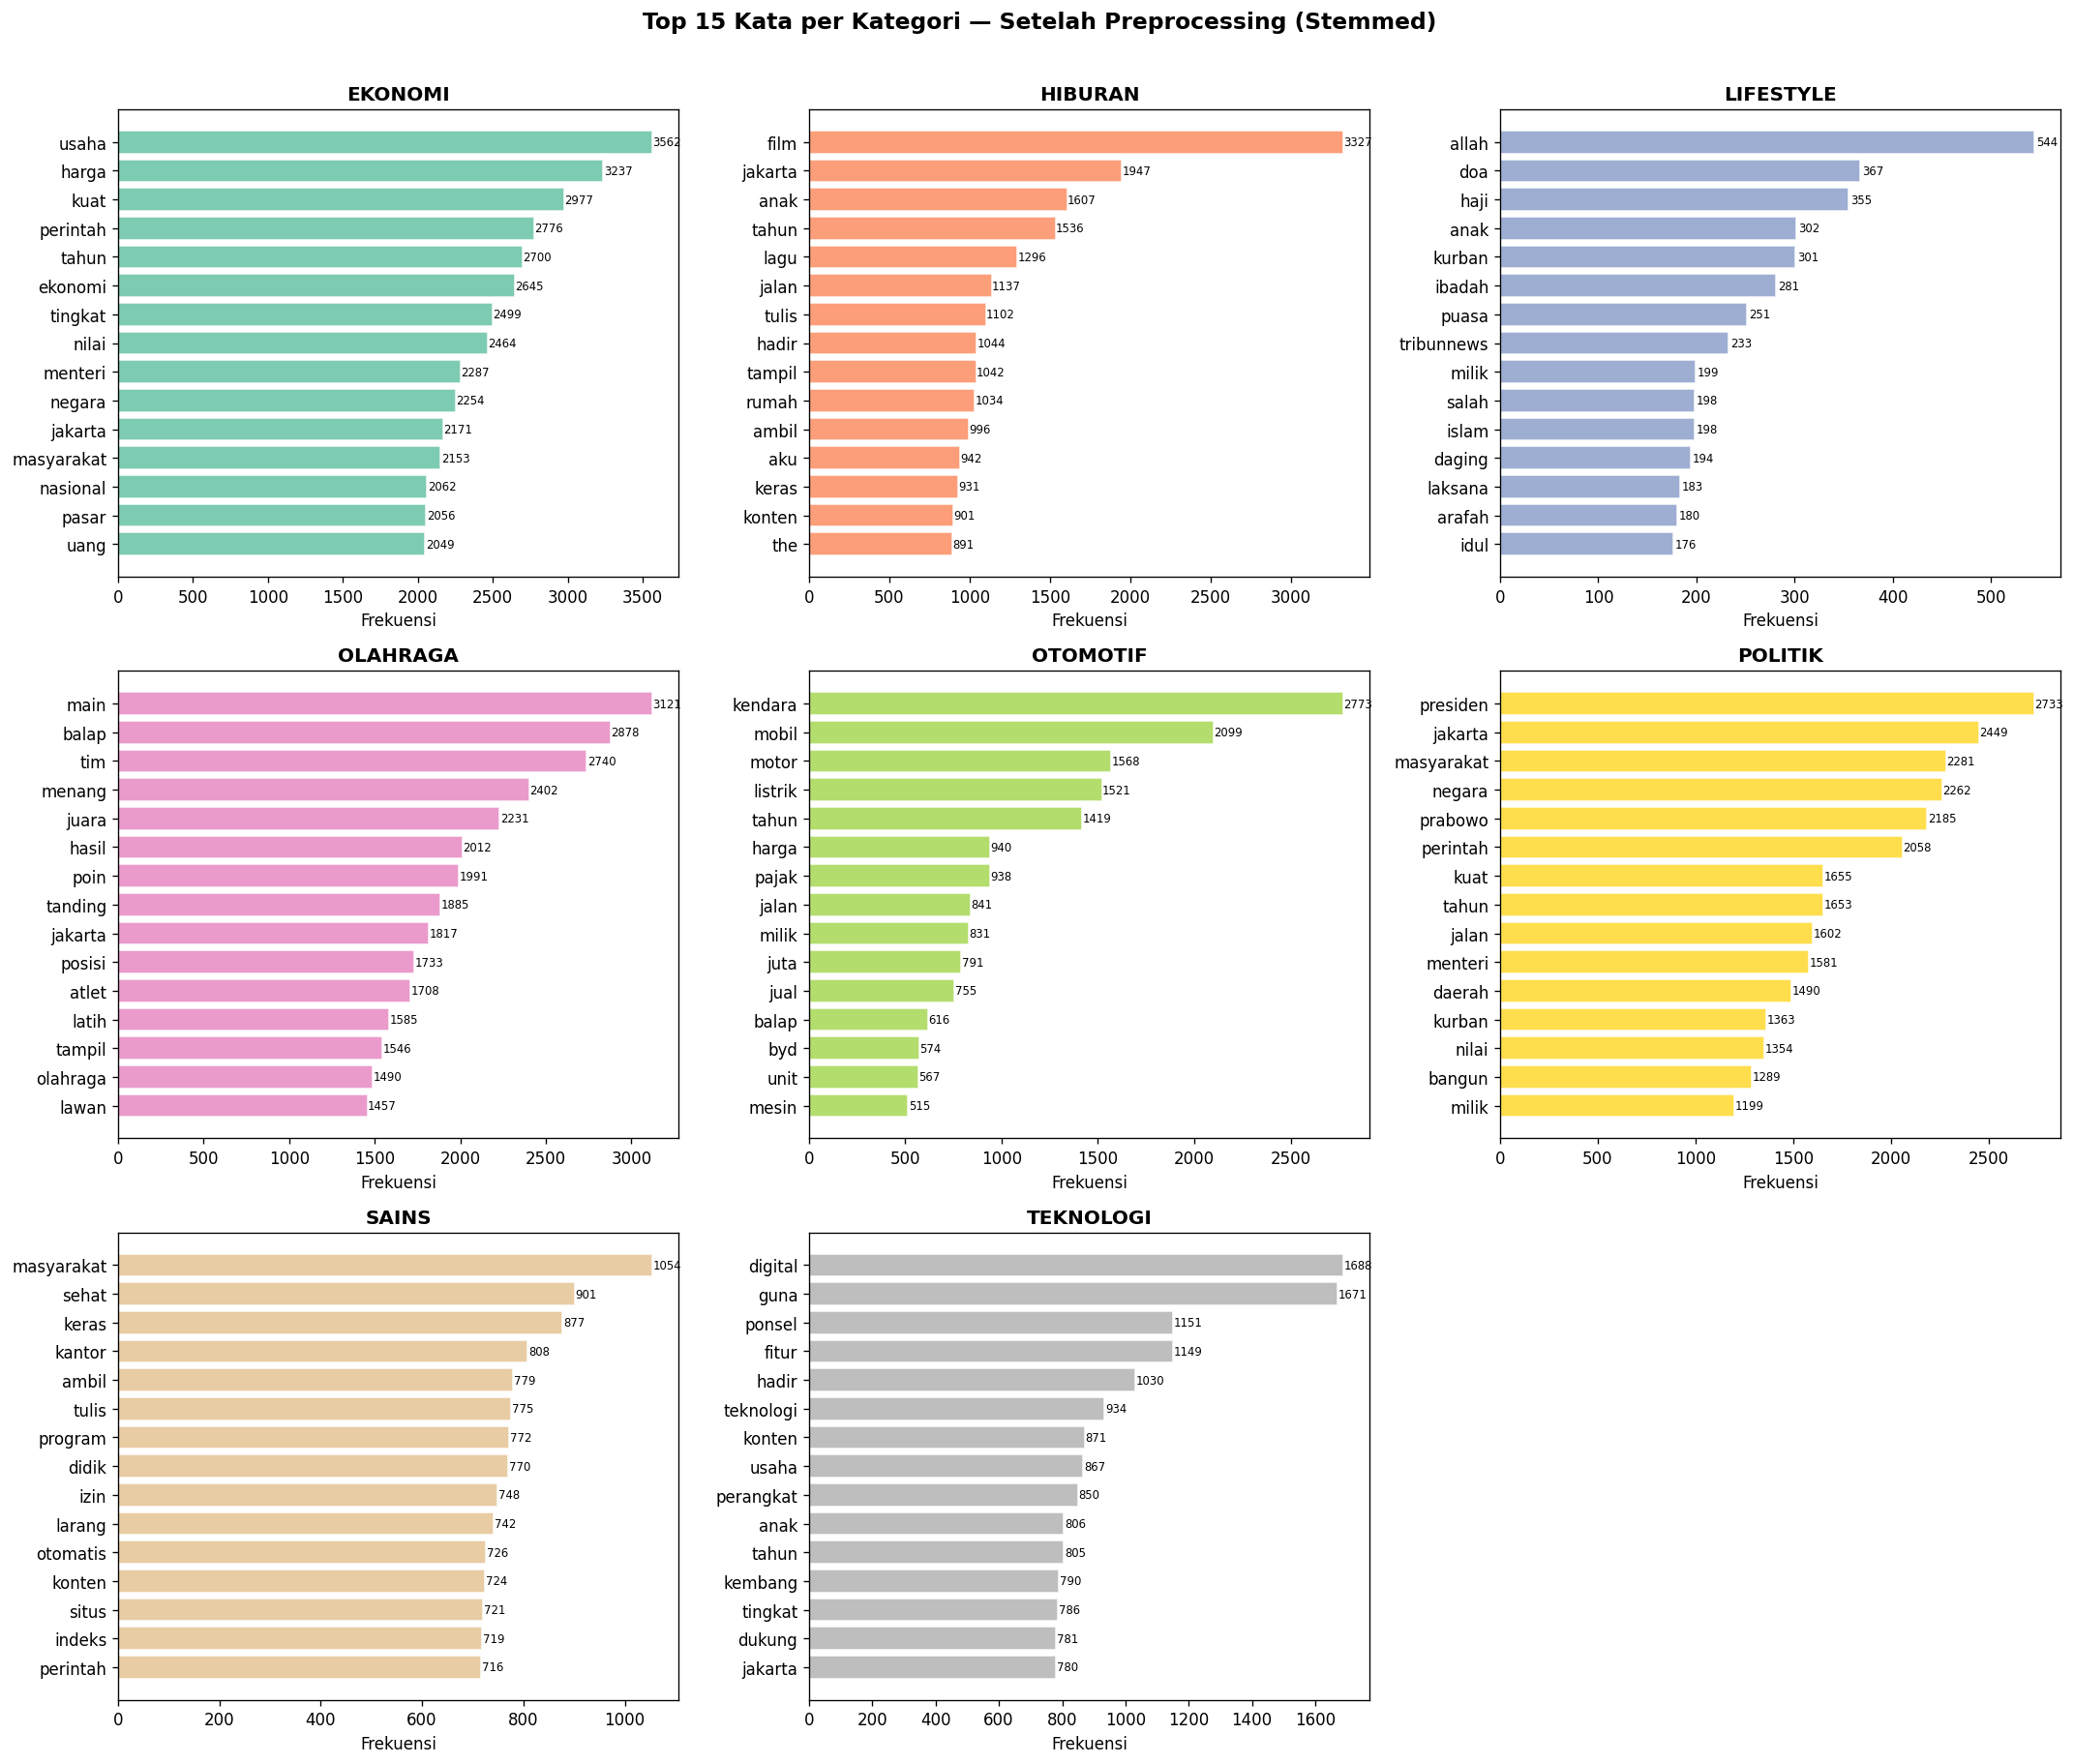

In [86]:
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5))
axes = axes.flatten()

for i, kat in enumerate(kat_wc):
    words_kat = ' '.join(df_clean[df_clean['kategori'] == kat]['teks_stem'].tolist()).split()
    top15     = Counter(words_kat).most_common(15)
    ww        = [w for w, _ in top15]
    cc        = [c for _, c in top15]
    color     = sns.color_palette(PALETTE, len(kat_wc))[i]
    axes[i].barh(ww[::-1], cc[::-1], color=color, alpha=0.85, edgecolor='white')
    axes[i].set_title(f'{kat.upper()}', fontweight='bold')
    axes[i].set_xlabel('Frekuensi')
    for bar, cnt in zip(axes[i].patches, cc[::-1]):
        axes[i].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                     str(cnt), va='center', fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Top 15 Kata per Kategori — Setelah Preprocessing (Stemmed)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/plot_10_topkata_post.png', bbox_inches='tight')
plt.show()

### 4.5 Vocabulary Size per Tahap

=== VOCABULARY SIZE ===
Setelah cleaning        : 60,450
Setelah stopword removal: 58,641  (reduksi 3.0%)
Setelah stemming        : 45,243  (reduksi 25.2%)


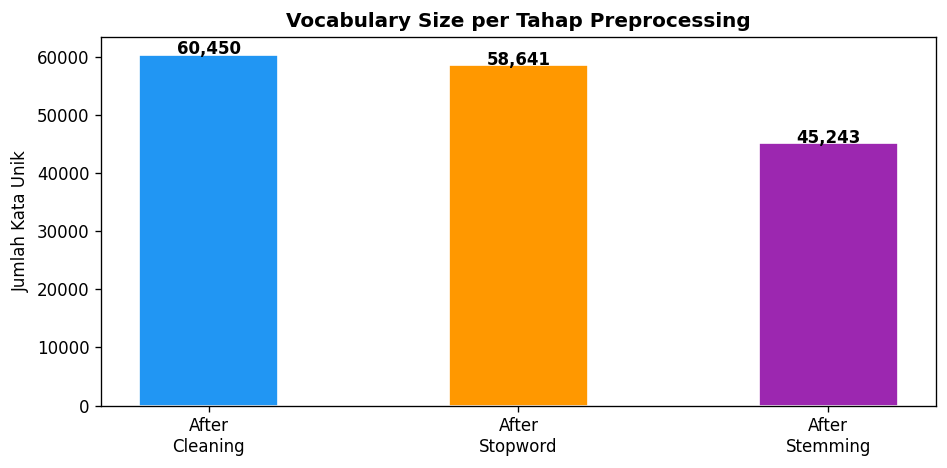

In [87]:
vocab_clean  = set(' '.join(df_clean['teks_clean'].tolist()).split())
vocab_nostop = set(' '.join(df_clean['teks_nostop'].tolist()).split())
vocab_stem   = set(' '.join(df_clean['teks_stem'].tolist()).split())

print('=== VOCABULARY SIZE ===')
print(f'Setelah cleaning        : {len(vocab_clean):,}')
print(f'Setelah stopword removal: {len(vocab_nostop):,}  (reduksi {(1 - len(vocab_nostop)/len(vocab_clean))*100:.1f}%)')
print(f'Setelah stemming        : {len(vocab_stem):,}  (reduksi {(1 - len(vocab_stem)/len(vocab_clean))*100:.1f}%)')

fig, ax = plt.subplots(figsize=(8, 4))
labels_v = ['After\nCleaning', 'After\nStopword', 'After\nStemming']
sizes    = [len(vocab_clean), len(vocab_nostop), len(vocab_stem)]
colors7  = ['#2196F3', '#FF9800', '#9C27B0']
bars6    = ax.bar(labels_v, sizes, color=colors7, edgecolor='white', width=0.45)
for bar, val in zip(bars6, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', fontweight='bold', fontsize=10)
ax.set_title('Vocabulary Size per Tahap Preprocessing', fontweight='bold')
ax.set_ylabel('Jumlah Kata Unik')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/plot_11_vocab_size.png', bbox_inches='tight')
plt.show()

---
## 5. Simpan Dataset & Corpus

In [89]:
# Dataset preprocessed lengkap — kolom 'portal' ikut disimpan
kolom_simpan = [
    'portal', 'kategori', 'judul', 'isi',
    'teks_clean', 'teks_norm', 'teks_nostop', 'teks_stem',
    'jumlah_kata', 'kata_clean', 'kata_nostop', 'kata_stem'
]
df_final = df_clean[kolom_simpan].copy()

df_final.to_csv(f'{SAVE_DIR}/dataset_preprocessed.csv', index=False)
df_final.to_pickle(f'{SAVE_DIR}/dataset_preprocessed.pkl')
print(f' dataset_preprocessed — shape: {df_final.shape}')

# Corpus tokenized → LDA / NMF
corpus_tokenized = [doc.split() for doc in df_final['teks_stem'].tolist()]
with open(f'{SAVE_DIR}/corpus_tokenized.json', 'w', encoding='utf-8') as f:
    json.dump(corpus_tokenized, f, ensure_ascii=False)
vocab_lda = set(w for doc in corpus_tokenized for w in doc)
print(f' corpus_tokenized.json — {len(corpus_tokenized):,} dokumen | {len(vocab_lda):,} vocab unik')

# Corpus BERT → BERTopic + IndoBERT / mBERT (tanpa stem)
corpus_bert = df_final['teks_nostop'].tolist()
with open(f'{SAVE_DIR}/corpus_bert.json', 'w', encoding='utf-8') as f:
    json.dump(corpus_bert, f, ensure_ascii=False)
print(f' corpus_bert.json      — {len(corpus_bert):,} dokumen')

# Metadata (label + portal + judul per dokumen)
meta = df_final[['portal', 'kategori', 'judul']].copy()
meta.to_json(f'{SAVE_DIR}/corpus_metadata.json', orient='records', force_ascii=False, indent=2)
print(f' corpus_metadata.json  — {len(meta):,} dokumen')

 dataset_preprocessed — shape: (9990, 12)
 corpus_tokenized.json — 9,990 dokumen | 45,243 vocab unik
 corpus_bert.json      — 9,990 dokumen
 corpus_metadata.json  — 9,990 dokumen
